### Gamma & Beta Distributions Parameter Define

In [26]:
import numpy as np
from scipy.stats import gaussian_kde
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import gaussian_kde, rankdata

In [27]:
ga = 3
gb = 5

ba = 5
bb = 7

In [28]:
gamma_skewness = 2/np.sqrt(ga)

def beta_skewness_cal(alpha, beta):
    num = 2 * (beta - alpha) * np.sqrt(alpha + beta + 1)
    den = (alpha + beta + 2) * np.sqrt(alpha * beta)
    return num / den

beta_skewness = beta_skewness_cal(ba, bb)


In [29]:
print("True Skewness of Gamma(3, 5): ", gamma_skewness, "True Skewness of Beta(5, 7): ", beta_skewness)

True Skewness of Gamma(3, 5):  1.1547005383792517 True Skewness of Beta(5, 7):  0.17412840006286973


In [30]:
#Sample size:
n = 20, 50, 100, 200, 500, 1000, 2000, 5000

### Two Method of Asymmetry Testing

 #### Adjusted Fisher-Pearson coefficient of skewness <br>
 Existing function in pakcage: <b>stats.skew(data, bias=False)</b>


#### Correlation-based asymmetry measure
The correlation-based asymmetry measure is defined as:

$$
\eta(X) = -\operatorname{Corr}(f(X), F(X))
$$

where:

- $X$ is a random variable sampled from the target distribution.
- $f(X)$ is the probability density function (PDF) evaluated at $X$.
- $F(X)$ is the cumulative distribution function (CDF) evaluated at $X$.
- $\operatorname{Corr}(\cdot,\cdot)$ represents the Pearson correlation coefficient.

The value of $\eta(X)$ lies in the range:

$$
-1 \leq \eta(X) \leq 1
$$

Interpretation:

- $\eta(X) = 0$: symmetric distribution
- $\eta(X) > 0$: positively asymmetric distribution
- $\eta(X) < 0$: negatively asymmetric distribution
- $|\eta(X)|$ closer to 1: stronger asymmetry

In [31]:
def asymmetry_eta(x, bandwidth=None):
    """
    Estimate eta using Patil et al.-style estimator:
    eta_hat = -Corr(f_hat(X_i), F_hat(X_i))

    f_hat(X_i): leave-one-out Gaussian KDE
    F_hat(X_i): leave-one-out empirical CDF
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)

    if n < 3:
        return np.nan

    # Silverman's bandwidth
    s = np.std(x, ddof=1)
    iqr = np.subtract(*np.percentile(x, [75, 25]))
    sigma = min(s, iqr / 1.349) if iqr > 0 else s
    if np.isclose(sigma, 0):
        sigma = s if s > 0 else 1.0
    h = bandwidth if bandwidth is not None else 0.9 * sigma * (n ** (-1 / 5))#calculate bandwidth
    if h <= 0:
        h = 1.06 * (s if s > 0 else 1.0) * (n ** (-1 / 5))

    # Leave-one-out KDE
    diffs = (x[None, :] - x[:, None]) / h#cal culate pairwise difference
    K = stats.norm.pdf(diffs)#fit standardized distance into gaussian kernel
    np.fill_diagonal(K, 0.0)#leave one out
    f_hat = K.sum(axis=1) / ((n - 1) * h)#KED for pdf

    # Leave-one-out empirical CDF
    indicators = (x[None, :] < x[:, None]).astype(float)
    np.fill_diagonal(indicators, 0.0)
    F_hat = indicators.sum(axis=1) / (n - 1)

    if np.std(f_hat, ddof=1) == 0 or np.std(F_hat, ddof=1) == 0:
        return np.nan

    eta = -np.corrcoef(f_hat, F_hat)[0, 1]#calculate correlation

    return eta



In [46]:
normal_test = np.random.normal(loc=0, scale=1, size=10000)

In [47]:
code_test = asymmetry_eta(normal_test)
print(code_test)

0.0008487560256242458


### List to save the average value of calculated skewness value

In [32]:
Method1_Gamma=[]
Method1_Beta=[]
Method2_Gamma=[]
Method2_Beta=[]

In [33]:
sample_sizes = []
for i in range (20,1000,10):
    sample_sizes.append(i)

    ndata = np.random.normal(1, 1, 10000)
    gdata = np.random.gamma(shape=ga, scale=gb, size=i)
    bdata = np.random.beta(ba, bb, size=i)

    s1g = stats.skew(gdata,bias=False)
    s2g =asymmetry_eta(gdata)
    Method1_Gamma.append(s1g)
    Method2_Gamma.append(s2g)

    s1b = stats.skew(bdata,bias=False)
    s2b = asymmetry_eta(bdata)
    Method1_Beta.append(s1b)
    Method2_Beta.append(s2b)
    

In [34]:
print(len(sample_sizes), len(Method1_Gamma))  # 确认长度一致

print(Method1_Gamma[:5])
print(Method2_Gamma[:5])
print(Method1_Beta[:5])
print(Method2_Beta[:5])

98 98
[np.float64(0.6468591037977394), np.float64(1.3747255427917098), np.float64(1.0086797622431323), np.float64(1.2019969218885038), np.float64(0.6667016194385456)]
[np.float64(0.8220832710642653), np.float64(0.6825180555741425), np.float64(0.7128316489540484), np.float64(0.665632877142402), np.float64(0.37158153993154325)]
[np.float64(0.2821790752335052), np.float64(-0.1927848430917327), np.float64(-0.06748492252893569), np.float64(-0.25292315180578445), np.float64(0.40526009706242805)]
[np.float64(0.5869764189479669), np.float64(-0.5112864489628398), np.float64(-0.1032617867095548), np.float64(-0.20433664048527017), np.float64(0.49693833097793666)]


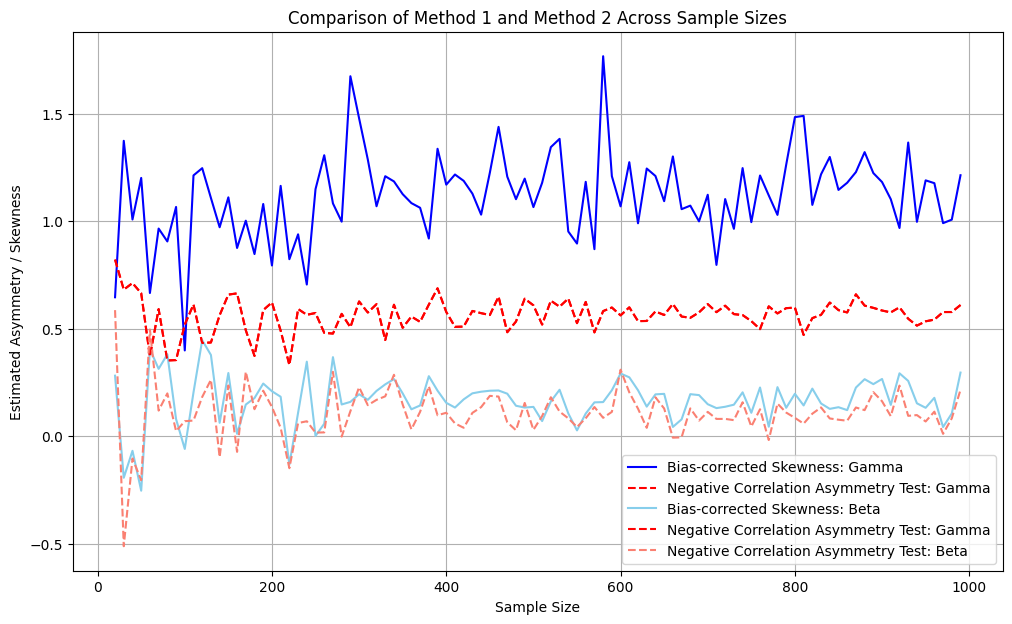

In [35]:
plt.figure(figsize=(12, 7))

# Method 1: blue family
plt.plot(sample_sizes, Method1_Gamma, color="blue", linestyle="-", label="Bias-corrected Skewness: Gamma")
plt.plot(sample_sizes, Method2_Gamma, color="red", linestyle="--", label="Negative Correlation Asymmetry Test: Gamma")
plt.plot(sample_sizes, Method1_Beta, color="skyblue", linestyle="-", label="Bias-corrected Skewness: Beta")

# Method 2: red family
plt.plot(sample_sizes, Method2_Gamma, color="red", linestyle="--", label="Negative Correlation Asymmetry Test: Gamma")
plt.plot(sample_sizes, Method2_Beta, color="salmon", linestyle="--", label="Negative Correlation Asymmetry Test: Beta")


plt.xlabel("Sample Size")
plt.ylabel("Estimated Asymmetry / Skewness")
plt.title("Comparison of Method 1 and Method 2 Across Sample Sizes")

plt.legend()
plt.grid(True)
plt.show()

In [36]:
Method1_Gamma_mean = []
Method1_Beta_mean = []
Method2_Gamma_mean = []
Method2_Beta_mean = []

Method1_Gamma_std = []
Method1_Beta_std = []
Method2_Gamma_std = []
Method2_Beta_std = []

sample_sizes = []

R = 1000   # Monte Carlo repetition

for i in range(20, 1000, 10):
    sample_sizes.append(i)

    temp_m1_gamma = []
    temp_m2_gamma = []
    temp_m1_beta = []
    temp_m2_beta = []

    for r in range(R):
        gdata = np.random.gamma(shape=ga, scale=gb, size=i)
        bdata = np.random.beta(ba, bb, size=i)

        s1g = stats.skew(gdata, bias=False)
        s2g = asymmetry_eta(gdata)

        s1b = stats.skew(bdata, bias=False)
        s2b = asymmetry_eta(bdata)

        temp_m1_gamma.append(s1g)
        temp_m2_gamma.append(s2g)
        temp_m1_beta.append(s1b)
        temp_m2_beta.append(s2b)

    Method1_Gamma_mean.append(np.nanmean(temp_m1_gamma))
    Method2_Gamma_mean.append(np.nanmean(temp_m2_gamma))
    Method1_Beta_mean.append(np.nanmean(temp_m1_beta))
    Method2_Beta_mean.append(np.nanmean(temp_m2_beta))

    Method1_Gamma_std.append(np.nanstd(temp_m1_gamma))
    Method2_Gamma_std.append(np.nanstd(temp_m2_gamma))
    Method1_Beta_std.append(np.nanstd(temp_m1_beta))
    Method2_Beta_std.append(np.nanstd(temp_m2_beta))

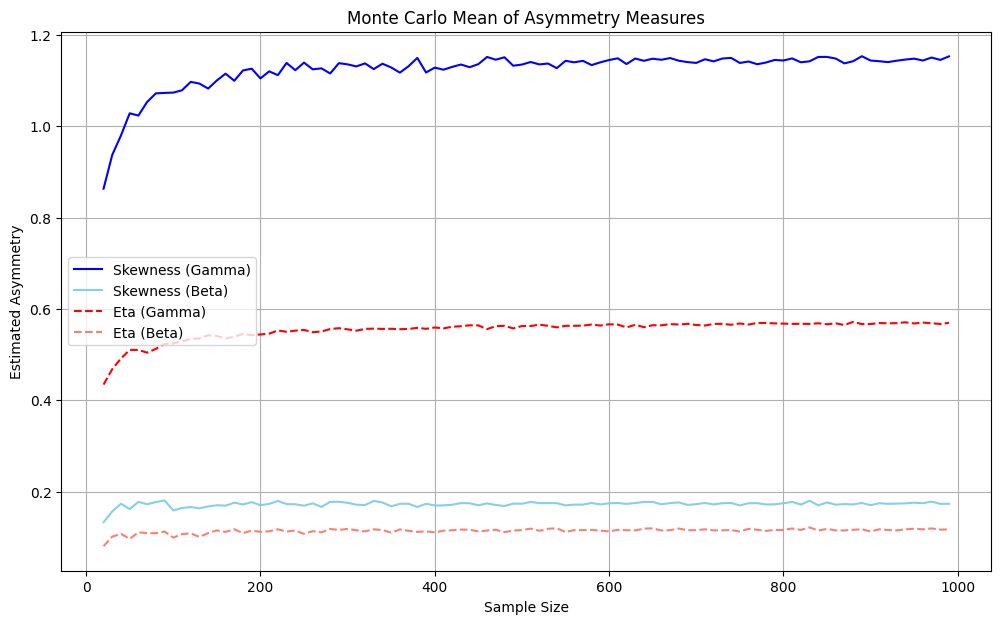

In [37]:
plt.figure(figsize=(12, 7))

# Method 1: blue family
plt.plot(sample_sizes, Method1_Gamma_mean, 
         color="blue", linestyle="-", 
         label="Skewness (Gamma)")

plt.plot(sample_sizes, Method1_Beta_mean, 
         color="skyblue", linestyle="-", 
         label="Skewness (Beta)")


# Method 2: red family
plt.plot(sample_sizes, Method2_Gamma_mean, 
         color="red", linestyle="--", 
         label="Eta (Gamma)")

plt.plot(sample_sizes, Method2_Beta_mean, 
         color="salmon", linestyle="--", 
         label="Eta (Beta)")


plt.xlabel("Sample Size")
plt.ylabel("Estimated Asymmetry")
plt.title("Monte Carlo Mean of Asymmetry Measures")

plt.legend()
plt.grid(True)
plt.show()